<a href="https://colab.research.google.com/github/SikandarHussain6858/ANN-and-DL-labs/blob/main/CS_320_Lab02_Perceptron_from_Scratch_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="font-family:Segoe UI,Calibri,sans-serif">
<div style="font-size:12px;letter-spacing:2px;color:#5B6770">NATIONAL UNIVERSITY OF SCIENCES AND TECHNOLOGY &nbsp;&middot;&nbsp; SEECS</div>
<div style="font-size:12px;letter-spacing:1px;color:#2A78D6;font-weight:600">CS-320 &nbsp;&middot;&nbsp; ARTIFICIAL NEURAL NETWORKS &amp; DEEP LEARNING &nbsp;&middot;&nbsp; BSAI</div>
<div style="font-size:26px;font-weight:700;color:#14375E;margin-top:6px">Lab 2 — The Perceptron from Scratch</div>
<div style="font-size:14px;color:#4A4A4A;margin-top:4px">3 hours &nbsp;&middot;&nbsp; CLO 1, CLO 4</div>
</div>

---

**Course Instructor:** Muhammad Babar Kamal &nbsp;|&nbsp; **Lab Engineer:** Ms Areeba Rameen &nbsp;|&nbsp; **Student name / CMS ID:** _______________

### What today is for

You will write, from nothing, the learning algorithm Frank Rosenblatt published in 1958 —
about twenty lines of NumPy — watch it solve three problems, and watch it fail on a fourth,
permanently and silently, in exactly the way that stalled the field for seventeen years.

The failure is the point. An algorithm that quietly does not work is far more dangerous than
one that crashes, and here you build the instrumentation that exposes it. That habit —
*measure the thing, do not assume it* — is what separates a working model from one that just
looks plausible.

**Part A** is a short NumPy warm-up. It exists because every shape bug you avoid here is an
hour you save later.

### Exercises

| Part | # | Exercise | Marks |
|---|---|----------|-------|
| A | A1 | Arrays, shapes, and the batch score in one expression | 10 |
| A | A2 | Boolean gates, derived by hand | 8 |
| A | A3 | Drawing a decision boundary | 7 |
| B | B1 | A `Perceptron` class — prediction | 8 |
| B | B2 | The learning rule — `fit` | 17 |
| B | B3 | Reproducing the hand-worked AND trace | 12 |
| B | B4 | OR, NAND, and seeing what was learned | 12 |
| B | B5 | XOR — instrumenting a failure | 16 |
| B | B6 | The two-layer XOR network, by hand | 10 |
| — | ★ | Optional: the pocket algorithm | +10 |

**Submission.** Restart the kernel, run everything top to bottom, confirm there are no
errors

**If you get stuck** for more than about twenty minutes on something that is not supposed to
be the hard part, ask. That is what the lab engineer is here for, and asking early is a
skill, not an admission.


# Part A — Warm-up

## Setup

Run this cell first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(precision=3, suppress=True)
rng = np.random.default_rng(0)

# the four points of a two-input truth table, and the gates we will use all day
X = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
GATES = {
    "AND":  np.array([0, 0, 0, 1]),
    "OR":   np.array([0, 1, 1, 1]),
    "NAND": np.array([1, 1, 1, 0]),
    "XOR":  np.array([0, 1, 1, 0]),
}
print("X shape", X.shape, " labels shape", GATES["AND"].shape)

X shape (4, 2)  labels shape (4,)


## Exercise A1 — Arrays, shapes, and the batch score  

**Why this matters.** Almost every bug you will hit in this course is a shape bug, and every
one of them is preventable by the habit of saying, before you run a line, what shape it
produces.

**The conventions used throughout this course**

| symbol | meaning | shape |
|---|---|---|
| `X` | a batch of inputs, one **row per example** | `(m, n)` |
| `y` | the labels | `(m,)` |
| `w` | the weight vector of one unit | `(n,)` |
| `b` | the bias of one unit | scalar |
| `z` | the scores of the whole batch | `(m,)` |

Note the difference between `(m,)` — a 1-D array — and `(m, 1)` — a 2-D column. NumPy will
broadcast one into the other without complaint and hand you a silent `(m, m)` result. That
is the most common cause of a program that runs, produces numbers, and is wrong.

**Task A1.1 — predict before you run.** Write your predicted shape as a comment for each
line, *then* run the cell. For any you got wrong, work out why before moving on; do not just
correct the comment.

In [2]:
a = np.arange(6)              # shape?
b_ = a.reshape(2, 3)          # shape?
c = b_.T                      # shape?
d = a[:, None]                # shape?    <- the (m,) -> (m,1) trick
e = a[None, :]                # shape?

for name, arr in [("a", a), ("b_", b_), ("c", c), ("d", d), ("e", e)]:
    print(f"{name:3s} {str(arr.shape):8s}")

# TODO — write your predictions here BEFORE running:
# Predictions:
# a  -> (6,)
# b_ -> (2, 3)
# c  -> (3, 2)
# d  -> (6, 1)
# e  -> (1, 6)

a   (6,)    
b_  (2, 3)  
c   (3, 2)  
d   (6, 1)  
e   (1, 6)  


**Task A1.2 — the batch score in one expression.**

For a single example the score is $z = \mathbf{w}^\top\mathbf{x} + b$. For a whole batch
`X` of shape `(m, n)` and a weight vector `w` of shape `(n,)`:

```python
z = X @ w + b        #  (m, n) @ (n,)  ->  (m,)   then b broadcasts to every row
```

One line replaces two nested loops. Complete the cell: compute the scores of all four rows
of `X` in **one expression**, then threshold them with `np.where`.

In [3]:
w = np.array([1.0, 1.0])
b = -1.5

z = X @ w + b                 # (4,2) @ (2,) → (4,)
y_hat = np.where(z >= 0, 1, 0)  # if score >= 0 → 1, otherwise → 0

print("scores      ", z)         # [-1.5 -0.5 -0.5  0.5]
print("predictions ", y_hat)     # [0 0 0 1]
print("is this AND?", np.array_equal(y_hat, GATES["AND"]))

scores       [-1.5 -0.5 -0.5  0.5]
predictions  [0 0 0 1]
is this AND? True


## Exercise A2 — Boolean gates, derived by hand  

Find `w` and `b` for **OR** and for **NAND** *by reasoning*, not by searching numerically.

Think geometrically: the line $w_1x_1 + w_2x_2 + b = 0$ splits the square. Which corners
must end up on which side?

For each gate, write a comment saying **why** your choice works. A correct answer with no
justification scores half marks.

In [4]:
def check(name, w, b, target):
    pred = np.where(X @ w + b >= 0, 1, 0)
    ok = np.array_equal(pred, target)
    print(f"{name:5s} w={w}  b={b:+.1f}  ->  {pred}   {'PASS' if ok else 'FAIL'}")
    return ok

# TODO: replace the zeros with your hand-derived weights, and justify each in a comment
# OR: w1=w2=1 and b=-0.5.
# (0,0) gives -0.5 -> 0, while any input containing a 1 gives >= 0.5 -> 1.
check("OR", np.array([1.0, 1.0]), -0.5, GATES["OR"])
# NAND: w1=w2=-1 and b=1.5.
# The first three corners give >= 0.5 -> 1, while (1,1) gives -0.5 -> 0.
check("NAND", np.array([-1.0, -1.0]), 1.5, GATES["NAND"])

OR    w=[1. 1.]  b=-0.5  ->  [0 1 1 1]   PASS
NAND  w=[-1. -1.]  b=+1.5  ->  [1 1 1 0]   PASS


True

## Exercise A3 — Drawing a decision boundary  

You will reuse these three helpers every week for the rest of the semester, so write them
properly now.

To draw the boundary for a 2-D input, solve $w_1x_1 + w_2x_2 + b = 0$ for $x_2$:

$$x_2 = -\frac{w_1x_1+b}{w_2}.$$

**That formula divides by $w_2$.** When $w_2 = 0$ the boundary is a *vertical* line and the
formula is undefined; when $\mathbf{w} = \mathbf{0}$ there is no boundary at all. Marks are
awarded for handling both cases — a helper that crashes on $\mathbf{w}=(1,0)$ is incomplete.

Use **shape as well as colour** for the two classes. A figure that is only legible in colour
is not accessible, and that is a marked criterion all semester.

In [11]:
def plot_boundary(ax, w, b, xlim, **kw):
    """Draw w1*x1 + w2*x2 + b = 0 across xlim on the axes ax."""
    w = np.asarray(w, dtype=float)
    if np.allclose(w, 0):
        return None
    if np.isclose(w[1], 0):
        return ax.axvline(-b / w[0], **kw)
    xs = np.asarray(xlim)
    return ax.plot(xs, -(w[0] * xs + b) / w[1], **kw)

def scatter_classes(ax, X, y):
    """Class 1 as circles, class 0 as squares."""
    ax.scatter(X[y == 1, 0], X[y == 1, 1], marker="o", s=90,
               color="tab:blue", edgecolor="black", label="class 1", zorder=3)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], marker="s", s=90,
               color="tab:orange", edgecolor="black", label="class 0", zorder=3)

def shade_halfplanes(ax, w, b, xlim, ylim, n=300, alpha=0.12):
    """Tint the two half-planes."""
    xs = np.linspace(*xlim, n)
    ys = np.linspace(*ylim, n)
    xx, yy = np.meshgrid(xs, ys)
    z = w[0] * xx + w[1] * yy + b
    return ax.contourf(xx, yy, np.sign(z), levels=[-2, 0, 2],
                       colors=["tab:orange", "tab:blue"], alpha=alpha)

**Task A3.2.** Draw the AND gate with its boundary and shading. Set
`ax.set_aspect("equal")` — without it, later figures will make the weight vector look
non-perpendicular to the boundary, which is a visual lie. Label the axes and add a legend.

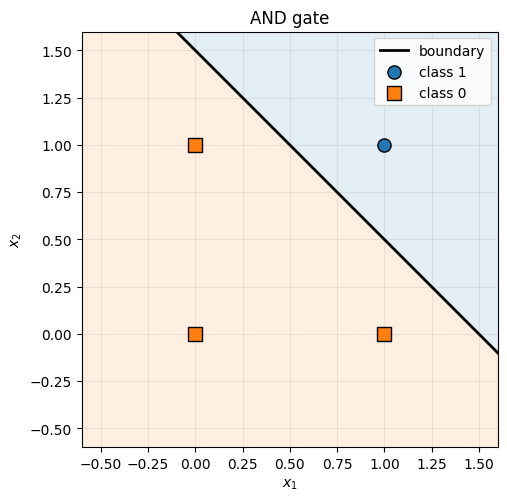

In [12]:
fig, ax = plt.subplots(figsize=(5.4, 5.4))
lim = (-0.6, 1.6)
w, b = np.array([1.0, 1.0]), -1.5

shade_halfplanes(ax, w, b, lim, lim)
plot_boundary(ax, w, b, lim, color="black", linewidth=2, label="boundary")
scatter_classes(ax, X, GATES["AND"])
ax.set(xlim=lim, ylim=lim, xlabel=r"$x_1$", ylabel=r"$x_2$", title="AND gate")
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.legend()

plt.show()

# Part B — The perceptron

## Exercise B1 — A `Perceptron` class: prediction  

**Design note.** `__init__` stores hyperparameters only; the parameters `w` and `b` are
created in `fit`. That is the convention scikit-learn uses, and it makes it structurally
obvious that an unfitted model has no parameters.

**Task B1.1.** Complete `net_input` (the batch of scores) and `predict` (the thresholded
output). Both take `X` of shape `(m, n)` and return shape `(m,)`. Use the convention that a
score of exactly zero predicts **1**.

In [13]:
class Perceptron:
    """Rosenblatt's perceptron with the {0, 1} step activation."""

    def __init__(self, eta=1.0, n_epochs=20, seed=0):
        self.eta = eta
        self.n_epochs = n_epochs
        self.seed = seed
        self.w = None
        self.b = None

    def net_input(self, X):
        """z = X w + b, shape (m,)."""
        # TODO
        return np.asarray(X) @ self.w + self.b
        raise NotImplementedError

    def predict(self, X):
        """1 where z >= 0, else 0. Shape (m,)."""
        # TODO
        return np.where(self.net_input(X) >= 0, 1, 0)
        raise NotImplementedError

    def score(self, X, y):
        return float((self.predict(X) == y).mean())


# check: hand-set the AND weights and confirm predict() reproduces the gate
p = Perceptron()
p.w, p.b = np.array([1.0, 1.0]), -1.5
print(p.predict(X))               # [0 0 0 1]
print(p.score(X, GATES["AND"]))   # 1.0

[0 0 0 1]
1.0


## Exercise B2 — The learning rule  

Implement

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat{y})\,\mathbf{x},
\qquad b \leftarrow b + \eta\,(y - \hat{y})$$

applied **only when the example is misclassified**, one example at a time.

**Task B2.1.** Add `fit(self, X, y)` to the class. It must:

1. initialise `w = zeros(n)` and `b = 0.0`;
2. loop for at most `n_epochs`;
3. visit the examples **in order** (do not shuffle — Exercise B3 needs a reproducible trace);
4. record in `self.history_` one dictionary per update: epoch, example index, input, target,
   prediction, and the resulting `w` and `b`;
5. record updates per epoch in `self.updates_per_epoch_`;
6. **stop early** when a whole epoch passes with no update, setting `self.converged_ = True`;
7. return `self`.

Recording the history is not decoration — Exercises B3 and B5 cannot be done without it, and
it carries marks of its own.

In [14]:
def fit(self, X, y):
    m, n = X.shape
    self.w = np.zeros(n)
    self.b = 0.0
    self.history_ = []
    self.updates_per_epoch_ = []
    self.converged_ = False

    for epoch in range(self.n_epochs):
        n_updates = 0
        for i in range(m):
            # TODO: predict for example
            y_hat = int(self.predict(X[i:i + 1])[0])
            # TODO: if wrong, update w and b, increment n_updates,
            #       and append a record to self.history_
            if y_hat != y[i]:
                error = y[i] - y_hat
                self.w += self.eta * error * X[i]
                self.b += self.eta * error
                n_updates += 1
                self.history_.append({
                    "epoch": epoch, "i": i, "x": X[i].copy(),
                    "target": int(y[i]), "prediction": y_hat,
                    "w": self.w.copy(), "b": float(self.b)
                })
            pass
        self.updates_per_epoch_.append(n_updates)
        # TODO: break out early when n_updates == 0, setting self.converged_
        if n_updates == 0:
            self.converged_ = True
            break
    return self

Perceptron.fit = fit          # attach the method to the class
print("fit attached")

fit attached


## Exercise B3 — Reproducing the hand-worked AND trace  

The strongest correctness test available to you today is that your code agrees, update for
update, with arithmetic done by hand. If the two disagree, one of them is wrong, and you
must find out which before going further.

**Task B3.1.** Fit with `eta=1.0` on AND and print one line per entry of `history_`. The
first line must read:

```
ep 0  i 0  x=[0. 0.]  y=0  yhat=1  ->  w=[0. 0.]  b=-1.0
```

**Task B3.2.** Report the total updates, the epochs used, and whether it converged. With
this ordering the run makes **11 updates over 6 epochs** and halts at **w = (2, 1), b = −3**.

**Task B3.3.** Answer in a comment: at the very first step the untrained model predicts 1
for *every* input. Why? Refer to the value of $z$ and to the convention that a score of zero
predicts 1.

If your numbers differ from those above, **say so explicitly and explain the difference**
rather than hiding it. An honest, correctly diagnosed discrepancy scores better than a
silent one.

In [15]:
clf = Perceptron(eta=1.0, n_epochs=30).fit(X, GATES["AND"])

# TODO: print one line per entry of clf.history_
for r in clf.history_:
    print(f"ep {r['epoch']}  i {r['i']}  x={r['x']}  y={r['target']}  "
          f"yhat={r['prediction']}  ->  w={r['w']}  b={r['b']:.1f}")
# TODO: print total updates, epochs used, clf.converged_, final w and b, accuracy
print("total updates:", len(clf.history_))
print("epochs used:", len(clf.updates_per_epoch_))
print("converged:", clf.converged_)
print("final w, b:", clf.w, clf.b)
print("accuracy:", clf.score(X, GATES["AND"]))

# Task B3.3 answer:
# Initially w = [0, 0] and b = 0, so z = 0 for every input. Because the
# step convention assigns z >= 0 to class 1, every initial prediction is 1.

ep 0  i 0  x=[0. 0.]  y=0  yhat=1  ->  w=[0. 0.]  b=-1.0
ep 0  i 3  x=[1. 1.]  y=1  yhat=0  ->  w=[1. 1.]  b=0.0
ep 1  i 0  x=[0. 0.]  y=0  yhat=1  ->  w=[1. 1.]  b=-1.0
ep 1  i 1  x=[0. 1.]  y=0  yhat=1  ->  w=[1. 0.]  b=-2.0
ep 1  i 3  x=[1. 1.]  y=1  yhat=0  ->  w=[2. 1.]  b=-1.0
ep 2  i 1  x=[0. 1.]  y=0  yhat=1  ->  w=[2. 0.]  b=-2.0
ep 2  i 2  x=[1. 0.]  y=0  yhat=1  ->  w=[1. 0.]  b=-3.0
ep 2  i 3  x=[1. 1.]  y=1  yhat=0  ->  w=[2. 1.]  b=-2.0
ep 3  i 2  x=[1. 0.]  y=0  yhat=1  ->  w=[1. 1.]  b=-3.0
ep 3  i 3  x=[1. 1.]  y=1  yhat=0  ->  w=[2. 2.]  b=-2.0
ep 4  i 1  x=[0. 1.]  y=0  yhat=1  ->  w=[2. 1.]  b=-3.0
total updates: 11
epochs used: 6
converged: True
final w, b: [2. 1.] -3.0
accuracy: 1.0


## Exercise B4 — OR, NAND, and seeing what was learned  

**Task B4.1.** Fit a fresh perceptron to each of AND, OR and NAND. Report the learned `w`,
`b`, the number of updates, and the accuracy.

**Task B4.2.** Plot the three side by side using your Part A helpers, with the learned
boundary and shaded half-planes. Title each panel with the gate name and the update count.

**Task B4.3.** Compare the learned weights with the ones you derived by hand in Exercise A2.
Are they the same? *Should* they be? Answer in a comment, referring to scale invariance and
to the fact that the algorithm stops at the first solution it finds.

AND: w=[2. 1.], b=-3.0, updates=11, accuracy=1.00
OR: w=[1. 1.], b=-1.0, updates=5, accuracy=1.00
NAND: w=[-2. -1.], b=2.0, updates=10, accuracy=1.00


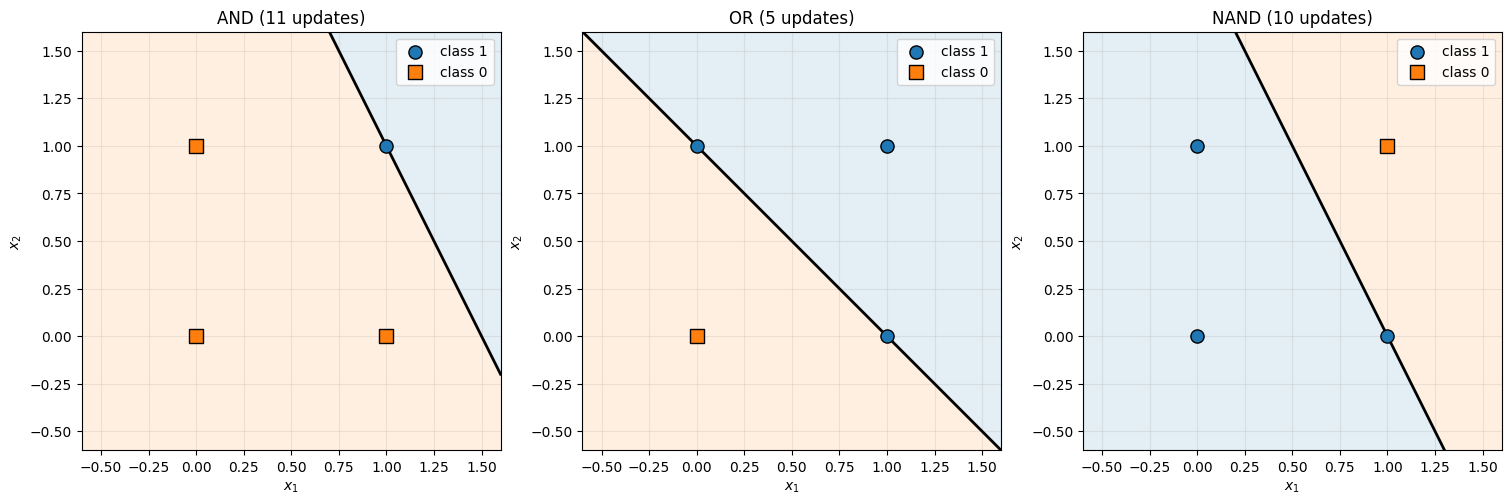

In [16]:
# TODO B4.1: fit AND, OR, NAND and report

# TODO B4.2: three-panel figure
models = {}
for name in ["AND", "OR", "NAND"]:
    model = Perceptron(eta=1.0, n_epochs=30).fit(X, GATES[name])
    models[name] = model
    print(f"{name}: w={model.w}, b={model.b:.1f}, updates={len(model.history_)}, "
          f"accuracy={model.score(X, GATES[name]):.2f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), constrained_layout=True)
lim = (-0.6, 1.6)
for ax, (name, model) in zip(axes, models.items()):
    shade_halfplanes(ax, model.w, model.b, lim, lim)
    plot_boundary(ax, model.w, model.b, lim, color="black", linewidth=2)
    scatter_classes(ax, X, GATES[name])
    ax.set(xlim=lim, ylim=lim, xlabel=r"$x_1$", ylabel=r"$x_2$",
           title=f"{name} ({len(model.history_)} updates)")
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.legend()
plt.show()
# Task B4.3 answer:
# Task B4.3 answer:
# They need not be identical. Multiplying (w, b) by any positive constant leaves
# all classifications unchanged (scale invariance), and many different separating
# lines work. The perceptron stops at the first separating solution it encounters.

## Exercise B5 — XOR: instrumenting a failure

This is the exercise the whole lab exists for. You know from the reading that no perceptron
computes XOR. Knowing it and *seeing* it are different things.

**Task B5.1.** Fit on XOR with `n_epochs=60`. Report `converged_`, the final accuracy, and
the first twenty entries of `updates_per_epoch_`.

**Task B5.2.** Plot updates per epoch for XOR and for AND on the same axes. Describe the
difference in a comment, and state what symptom a user who had **not** instrumented the run
would have seen.

**Task B5.3.** Collect the `(w, b)` state after every update and detect a repeat. Print the
repeated state, the two update indices, and the period. *A trajectory that revisits a state
can never terminate* — this is a proof, not an observation.

**Task B5.4.** Plot the best boundary the run ever visited, judged by training accuracy.

**Task B5.5.** Separately, search a coarse grid of $(w_1, w_2, b)$ and report the highest
accuracy **any** single perceptron achieves on XOR. Explain the number by reference to the
four contradictory constraints.

**Note carefully that the answers to B5.4 and B5.5 are different numbers.** Explaining why
is the most important sentence you will write today.

converged: False
final accuracy: 0.5
first 20 epoch update counts: [3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]


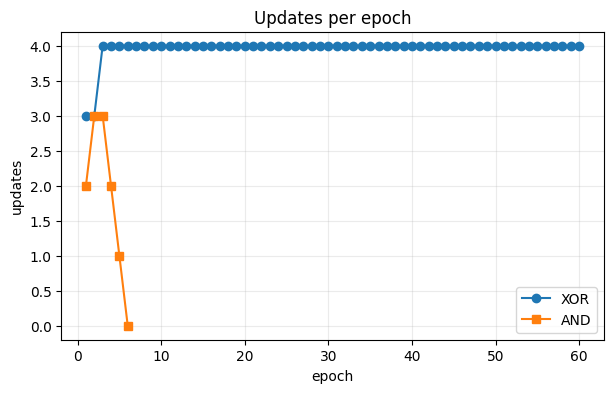

repeated state (w1, w2, b): (np.float64(-1.0), np.float64(0.0), np.float64(-1.0))
update indices: 3 7 period: 4
best trajectory accuracy: 0.5 at state: [0. 0.] 0.0


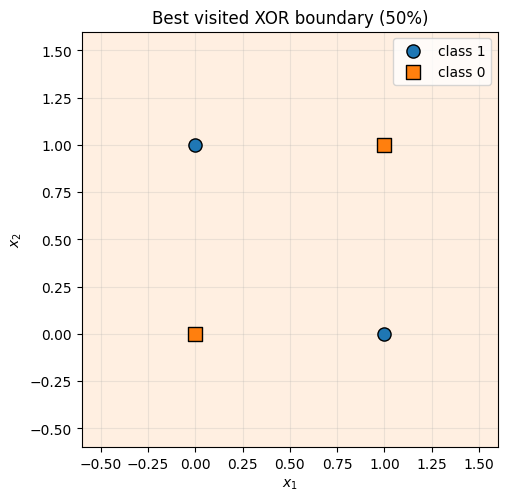

grid-search best accuracy, w, b: (np.float64(0.75), array([-3., -3.]), np.float64(3.0))


In [17]:
# TODO B5.1
# TODO B5.2
# TODO B5.3 — detect a repeated (w, b) state
# TODO B5.4 — best-ever boundary, plotted
# TODO B5.5 — grid search over (w1, w2, b)
xor_clf = Perceptron(eta=1.0, n_epochs=60).fit(X, GATES["XOR"])
print("converged:", xor_clf.converged_)
print("final accuracy:", xor_clf.score(X, GATES["XOR"]))
print("first 20 epoch update counts:", xor_clf.updates_per_epoch_[:20])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, len(xor_clf.updates_per_epoch_) + 1), xor_clf.updates_per_epoch_, marker="o", label="XOR")
ax.plot(range(1, len(clf.updates_per_epoch_) + 1), clf.updates_per_epoch_, marker="s", label="AND")
ax.set(xlabel="epoch", ylabel="updates", title="Updates per epoch")
ax.grid(alpha=0.25); ax.legend(); plt.show()

states = [(0.0, 0.0, 0.0)] + [tuple(np.r_[r["w"], r["b"]]) for r in xor_clf.history_]
seen, repeat = {}, None
for update_idx, state in enumerate(states):
    if state in seen:
        repeat = (state, seen[state], update_idx)
        break
    seen[state] = update_idx
if repeat is not None:
    state, first_idx, second_idx = repeat
    print("repeated state (w1, w2, b):", state)
    print("update indices:", first_idx, second_idx, "period:", second_idx - first_idx)

visited = [(np.zeros(2), 0.0)] + [(r["w"], r["b"]) for r in xor_clf.history_]
visited_acc = [np.mean(np.where(X @ wv + bv >= 0, 1, 0) == GATES["XOR"]) for wv, bv in visited]
best_idx = int(np.argmax(visited_acc))
best_w, best_b = visited[best_idx]
print("best trajectory accuracy:", visited_acc[best_idx], "at state:", best_w, best_b)
fig, ax = plt.subplots(figsize=(5.4, 5.4))
lim = (-0.6, 1.6)
shade_halfplanes(ax, best_w, best_b, lim, lim)
plot_boundary(ax, best_w, best_b, lim, color="black", linewidth=2)
scatter_classes(ax, X, GATES["XOR"])
ax.set(xlim=lim, ylim=lim, xlabel=r"$x_1$", ylabel=r"$x_2$", title=f"Best visited XOR boundary ({visited_acc[best_idx]:.0%})")
ax.set_aspect("equal"); ax.grid(alpha=0.25); ax.legend(); plt.show()

grid = np.arange(-3.0, 3.01, 0.5)
grid_best = (-1.0, None, None)
for w1 in grid:
    for w2 in grid:
        for bg in grid:
            pred = np.where(X @ np.array([w1, w2]) + bg >= 0, 1, 0)
            acc = np.mean(pred == GATES["XOR"])
            if acc > grid_best[0]:
                grid_best = (acc, np.array([w1, w2]), bg)
print("grid-search best accuracy, w, b:", grid_best)

# Task B5.2 answer: AND reaches zero updates and stops; XOR keeps updating in a
# repeating pattern. Without instrumentation, a user would only see arbitrary final
# weights after the epoch budget, with no clear warning that learning failed.
# Task B5.5 answer: A line can satisfy at most three of XOR's four contradictory
# corner constraints, hence 75%. The fixed-order trajectory can have a lower best
# score because it cycles through only a few states; grid search visits other states.


## Exercise B6 — The two-layer XOR network, by hand  

XOR is OR combined with NAND by an AND, and each of those three is a perceptron. So three
perceptrons in two layers compute XOR. You will type in the nine numbers and verify the
forward pass.

$$W^{[1]} = \begin{bmatrix}1 & 1\\ -1 & -1\end{bmatrix},\quad
\mathbf{b}^{[1]} = \begin{bmatrix}-0.5\\ 1.5\end{bmatrix},\quad
W^{[2]} = \begin{bmatrix}1 & 1\end{bmatrix},\quad
\mathbf{b}^{[2]} = \begin{bmatrix}-1.5\end{bmatrix}.$$

**Task B6.1.** Write `forward(X, W1, b1, W2, b2)` doing the whole batch in two matrix
products, returning `(Z1, H, y_hat)`.

**Task B6.2.** Print `Z1`, `H` and `y_hat`, and confirm `y_hat` is XOR.

**Task B6.3.** Two rows of `H` are identical. Which, and why does that matter? This is the
mechanism of the entire course — answer it carefully.

**Task B6.4.** Plot the input space and the hidden space side by side, showing four points
becoming three and one line separating them.

Z1:
 [[-0.5  1.5]
 [ 0.5  0.5]
 [ 0.5  0.5]
 [ 1.5 -0.5]]
H:
 [[0 1]
 [1 1]
 [1 1]
 [1 0]]
y_hat: [0 1 1 0]
is XOR? True


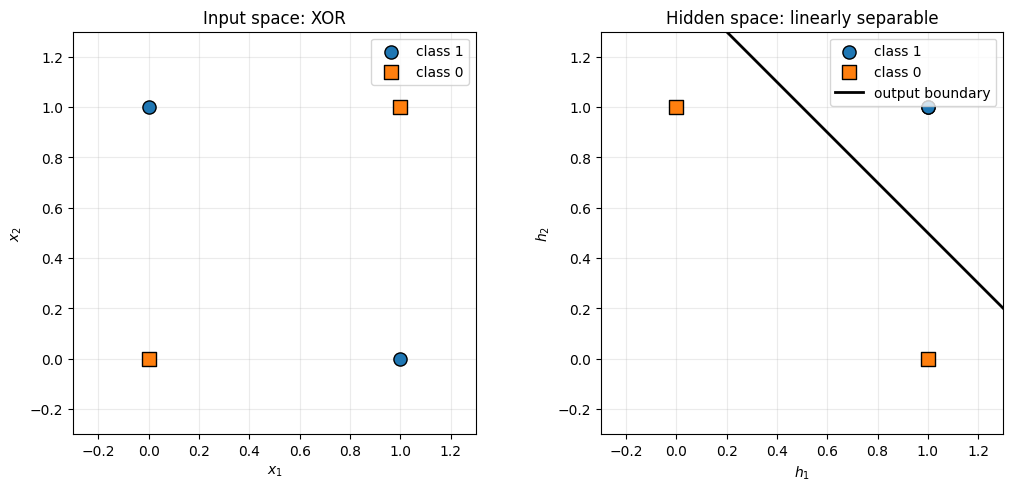

In [18]:
W1 = np.array([[1., 1.], [-1., -1.]])
b1 = np.array([-0.5, 1.5])
W2 = np.array([[1., 1.]])
b2 = np.array([-1.5])

def forward(X, W1, b1, W2, b2):
    # TODO: Z1 = X @ W1.T + b1 ; H = step(Z1) ; Z2 = H @ W2.T + b2 ; yhat = step(Z2)
    Z1 = X @ W1.T + b1
    H = np.where(Z1 >= 0, 1, 0)
    Z2 = H @ W2.T + b2
    y_hat = np.where(Z2.ravel() >= 0, 1, 0)
    return Z1, H, y_hat
    raise NotImplementedError

# TODO B6.2: print Z1, H, y_hat and compare with GATES["XOR"]
Z1, H, y_hat = forward(X, W1, b1, W2, b2)
print("Z1:\n", Z1)
print("H:\n", H)
print("y_hat:", y_hat)
print("is XOR?", np.array_equal(y_hat, GATES["XOR"]))

# Task B6.3 answer:
# Inputs (0, 1) and (1, 0) both map to H = (1, 1). This merges the two
# disconnected positive XOR corners into one hidden representation; together with
# the other hidden points, the output layer can now separate the classes by one line.
# TODO B6.4: two-panel figure

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.8), constrained_layout=True)
scatter_classes(axes[0], X, GATES["XOR"])
axes[0].set(title="Input space: XOR", xlabel=r"$x_1$", ylabel=r"$x_2$", xlim=(-0.3, 1.3), ylim=(-0.3, 1.3))
scatter_classes(axes[1], H, GATES["XOR"])
plot_boundary(axes[1], W2.ravel(), float(b2[0]), (-0.3, 1.3), color="black", linewidth=2, label="output boundary")
axes[1].set(title="Hidden space: linearly separable", xlabel=r"$h_1$", ylabel=r"$h_2$", xlim=(-0.3, 1.3), ylim=(-0.3, 1.3))
for ax in axes:
    ax.set_aspect("equal"); ax.grid(alpha=0.25); ax.legend()
plt.show()

## ★ Optional challenge — the pocket algorithm  

Implement Gallant's pocket algorithm: run the ordinary perceptron on XOR, but keep the best
weight vector seen so far — judged by accuracy over the whole training set — and return that
instead of the last one. Show that it returns a 75% solution reliably, whereas the plain
algorithm returns whatever it happened to hold when the epoch budget ran out.

Then answer: **what did you have to add to the algorithm to do this, and why is that
addition the seed of loss functions and gradient descent?**

*Hint on a subtlety worth reporting:* from a zero start with the examples in a fixed order,
the trajectory falls into a short cycle that never passes through a 75% state, so the pocket
alone would still return 50%. Shuffling the presentation order fixes that. The pocket idea
and the presentation order are two separate repairs to two separate defects — saying so
explicitly earns the bonus marks.

In [19]:
# TODO (bonus)
def pocket_perceptron(X, y, eta=1.0, n_epochs=60, seed=0):
    rng_local = np.random.default_rng(seed)
    w, b = np.zeros(X.shape[1]), 0.0
    best_w, best_b, best_acc = w.copy(), b, np.mean(np.where(X @ w + b >= 0, 1, 0) == y)
    for _ in range(n_epochs):
        for i in rng_local.permutation(len(X)):
            y_hat = int(X[i] @ w + b >= 0)
            if y_hat != y[i]:
                error = y[i] - y_hat
                w += eta * error * X[i]
                b += eta * error
                acc = np.mean(np.where(X @ w + b >= 0, 1, 0) == y)
                if acc > best_acc:
                    best_w, best_b, best_acc = w.copy(), float(b), float(acc)
    return best_w, best_b, best_acc

for seed in range(5):
    pw, pb, pa = pocket_perceptron(X, GATES["XOR"], seed=seed)
    print(f"seed {seed}: pocket w={pw}, b={pb:.1f}, accuracy={pa:.0%}")

# The pocket adds an explicit whole-dataset objective (accuracy), evaluates every
# candidate state, and remembers the best. This is the seed of loss-based optimization:
# define a scalar measure of error and use it to choose parameters. Shuffling is a
# separate repair: it lets training escape the short fixed-order cycle so a 75% state
# is actually visited; the pocket then retains that state.

seed 0: pocket w=[-1.  1.], b=-1.0, accuracy=75%
seed 1: pocket w=[-1.  1.], b=-1.0, accuracy=75%
seed 2: pocket w=[1. 1.], b=-1.0, accuracy=75%
seed 3: pocket w=[ 1. -1.], b=-1.0, accuracy=75%
seed 4: pocket w=[-1.  1.], b=-1.0, accuracy=75%


---

### Before you submit

- [ ] Kernel → Restart & Run All, no errors.
- [ ] Every `TODO` and every `raise NotImplementedError` gone.
- [ ] Your five shape predictions in A1.1 left in place as comments.
- [ ] Geometric justifications for OR and NAND in A2.
- [ ] `plot_boundary` handles both `w[1] == 0` and `w == 0`.
- [ ] The AND trace printed and compared with the hand-worked trace.
- [ ] The repeated-state demonstration in B5.3 actually prints a repeat and a period.
- [ ] All written answers present as comments: B3.3, B4.3, B5.2, B5.5, B6.3.
- [ ] Renamed to `Lab2_<yourCMSID>.ipynb`.

### One thing to take away

You have met the exact wall the field hit in 1969 — and you have the two-layer network that
gets past it, with the weights typed in by hand. What is still missing is a way to *find*
those nine numbers automatically instead of typing them in.